In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler

In [2]:
def normalize_data_z_score(data: np.ndarray) -> np.ndarray:
    num_samples, sample_length, num_channels = data.shape
    data_reshaped = data.reshape(-1, num_channels)
    scaler = StandardScaler()
    data_normalized = scaler.fit_transform(data_reshaped)
    return data_normalized.reshape(num_samples, sample_length, num_channels)

In [3]:
import scipy.signal as signal
def filter_signal(signal_data, axis=0, fs=100, lowcut=0.5, highcut=45.0):
        nyquist = 0.5 * fs
        low = lowcut / nyquist
        high = highcut / nyquist
        b, a = signal.butter(4, [low, high], btype='band')
        return signal.filtfilt(b, a, signal_data, axis=axis)

In [4]:
path_load = '../../source/data_source_sub'


##train
X_train = np.load(os.path.join(path_load, 'Y_train.npy'))
X_train = normalize_data_z_score(X_train)
X_train = filter_signal(X_train, axis=1, fs=100, lowcut=0.5, highcut=45.0)

y_train = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
y_train = y_train.drop(columns=['ecg_id'])
y_train = y_train.to_numpy(dtype=np.float32)

z_train = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
z_train = z_train.drop(columns=['ecg_id'])
z_train = z_train.to_numpy(dtype=np.float32)

##test
X_test = np.load(os.path.join(path_load, 'Y_test.npy'))
X_test = normalize_data_z_score(X_test)
X_test = filter_signal(X_test, axis=1, fs=100, lowcut=0.5, highcut=45.0)

y_test = pd.read_csv(os.path.join(path_load, 'Z_test.csv'))
y_test = y_test.drop(columns=['ecg_id'])
y_test = y_test.to_numpy(dtype=np.float32)

z_test = pd.read_csv(os.path.join(path_load, 'T_test.csv'))
z_test = z_test.drop(columns=['ecg_id'])
z_test = z_test.to_numpy(dtype=np.float32)

##validation
X_val = np.load(os.path.join(path_load, 'Y_valid.npy'))
X_val = normalize_data_z_score(X_val)
X_val = filter_signal(X_val, axis=1, fs=100, lowcut=0.5, highcut=45.0)

y_val = pd.read_csv(os.path.join(path_load, 'Z_valid.csv'))
y_val = y_val.drop(columns=['ecg_id'])
y_val = y_val.to_numpy(dtype=np.float32)

z_val = pd.read_csv(os.path.join(path_load, 'T_valid.csv'))
z_val = z_val.drop(columns=['ecg_id'])
z_val = z_val.to_numpy(dtype=np.float32)

table = [
    ["X_train", X_train.shape],
    ["y_train", y_train.shape],
    ["z_train", z_train.shape],
    ["X_test", X_test.shape],
    ["y_test", y_test.shape],
    ["z_test", z_test.shape],
    ["X_val", X_val.shape],
    ["y_val", y_val.shape],
    ["z_val", z_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

+-----------+-------------------+
| Dataset   | Shape             |
+===========+===================+
| X_train   | (17418, 1000, 12) |
+-----------+-------------------+
| y_train   | (17418, 5)        |
+-----------+-------------------+
| z_train   | (17418, 23)       |
+-----------+-------------------+
| X_test    | (2198, 1000, 12)  |
+-----------+-------------------+
| y_test    | (2198, 5)         |
+-----------+-------------------+
| z_test    | (2198, 23)        |
+-----------+-------------------+
| X_val     | (2183, 1000, 12)  |
+-----------+-------------------+
| y_val     | (2183, 5)         |
+-----------+-------------------+
| z_val     | (2183, 23)        |
+-----------+-------------------+


In [5]:
columns_of_csv = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
label_map = {label: i for i, label in enumerate(columns_of_csv.columns[1:])}
print(label_map)

columns_of_csv = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
label_map_sub = {label: i for i, label in enumerate(columns_of_csv.columns[1:])}
print(label_map_sub)

superclass_dict = {
    'NORM': ['NORM'],
    'CD': ['LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB', 'IVCB'],
    'HYP': ['LVH', 'RVH', 'LAO/LAE', 'RAO/RAE', 'SEHYP'],
    'MI': ['AMI', 'IMI', 'LMI', 'PMI', 'ISCA', 'ISCI'],
    'STTC': ['ISC_', 'STTC', 'NST_']
}


{'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4}
{'NORM': 0, 'LAFB/LPFB': 1, 'IRBBB': 2, 'ILBBB': 3, 'CLBBB': 4, 'CRBBB': 5, '_AVB': 6, 'IVCB': 7, 'WPW': 8, 'LVH': 9, 'RVH': 10, 'LAO/LAE': 11, 'RAO/RAE': 12, 'SEHYP': 13, 'AMI': 14, 'IMI': 15, 'LMI': 16, 'PMI': 17, 'ISCA': 18, 'ISCI': 19, 'ISC_': 20, 'STTC': 21, 'NST_': 22}


+------------+---------+--------------+--------+---------+
| Subclass   |   Train |   Validation |   Test |   Total |
+============+=========+==============+========+=========+
| NORM       |    7596 |          955 |    963 |    9514 |
+------------+---------+--------------+--------+---------+
| CD         |    3907 |          495 |    496 |    4898 |
+------------+---------+--------------+--------+---------+
| HYP        |    2119 |          268 |    262 |    2649 |
+------------+---------+--------------+--------+---------+
| MI         |    4379 |          540 |    550 |    5469 |
+------------+---------+--------------+--------+---------+
| STTC       |    4186 |          528 |    521 |    5235 |
+------------+---------+--------------+--------+---------+


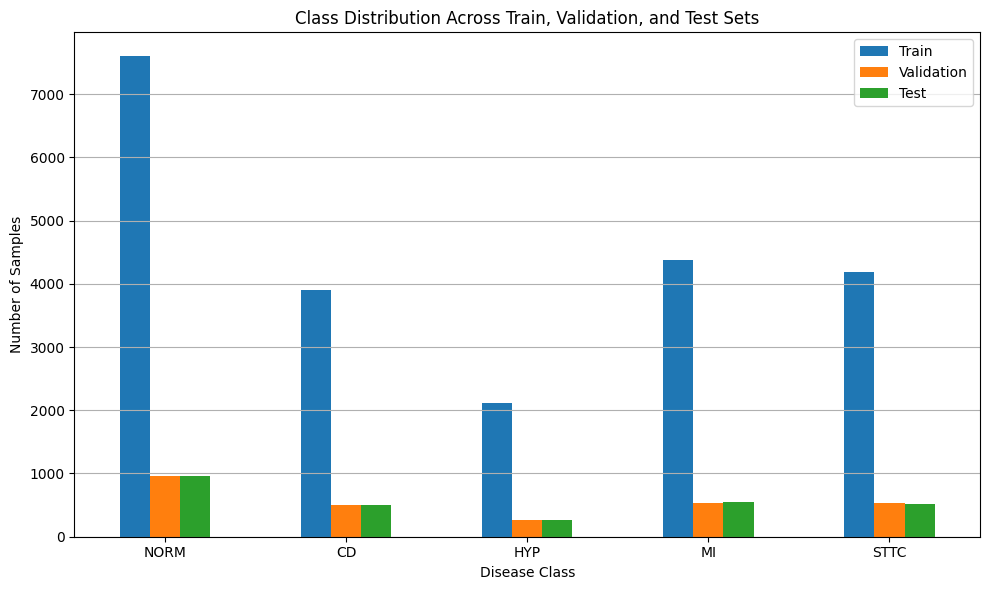

+------------+---------+--------------+--------+---------+
| Subclass   |   Train |   Validation |   Test |   Total |
+============+=========+==============+========+=========+
| NORM       |    7596 |          955 |    963 |    9514 |
+------------+---------+--------------+--------+---------+
| LAFB/LPFB  |    1437 |          181 |    179 |    1797 |
+------------+---------+--------------+--------+---------+
| IRBBB      |     894 |          112 |    112 |    1118 |
+------------+---------+--------------+--------+---------+
| ILBBB      |      62 |            7 |      8 |      77 |
+------------+---------+--------------+--------+---------+
| CLBBB      |     428 |           54 |     54 |     536 |
+------------+---------+--------------+--------+---------+
| CRBBB      |     432 |           55 |     54 |     541 |
+------------+---------+--------------+--------+---------+
| _AVB       |     658 |           83 |     82 |     823 |
+------------+---------+--------------+--------+--------

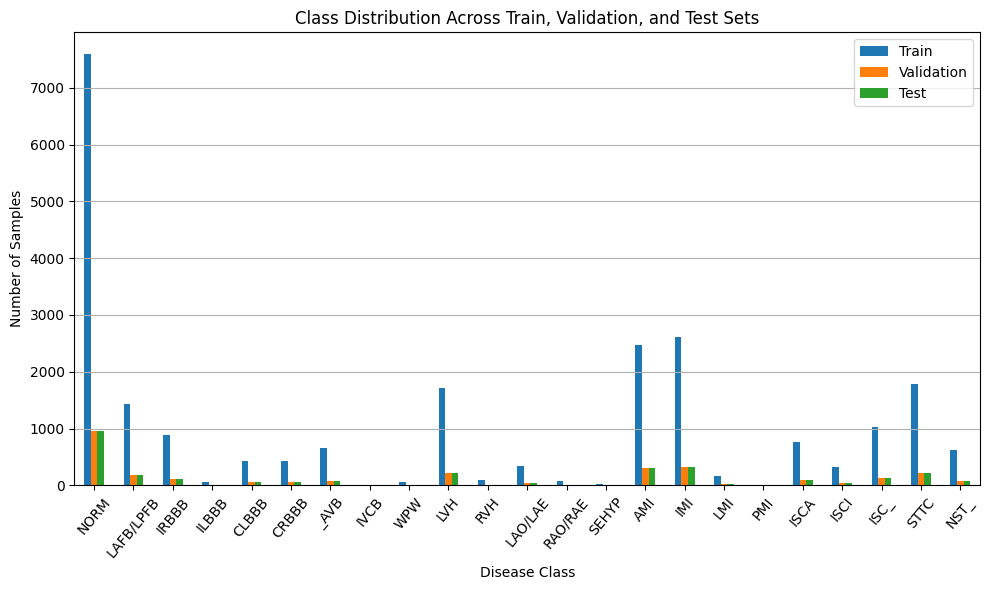

In [6]:
index_to_label = {v: k for k, v in label_map.items()}
# Convert one-hot to class labels
# num_classes = y_train.shape[1]  # Assuming y_train is the one-hot encoded matrix
# y_train_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_train], dtype=int)
# y_val_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_val], dtype=int)
# y_test_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_test], dtype=int)
num_y_train = np.sum(y_train, axis=0, dtype=int)
num_y_val = np.sum(y_val, axis=0, dtype=int)
num_y_test = np.sum(y_test, axis=0, dtype=int)


# Align the indices (classes 0–4)
all_classes = range(len(label_map))


# Prepare table for tabulate
table = []
for idx in all_classes:
    label = index_to_label[idx]
    table.append([label, num_y_train[idx], num_y_val[idx], num_y_test[idx], num_y_train[idx] + num_y_val[idx] + num_y_test[idx]])

from tabulate import tabulate
print(tabulate(table, headers=["Subclass", "Train", "Validation", "Test", "Total"], tablefmt="grid"))
# Combine into DataFrame for plotting
df = pd.DataFrame({
    'Train': num_y_train,
    'Validation': num_y_val,
    'Test': num_y_test
})
df.index = df.index.map(index_to_label)

# Plot
plt.figure(figsize=(10, 6))  # Width=10, Height=6
df.plot(kind='bar', ax=plt.gca())
plt.title("Class Distribution Across Train, Validation, and Test Sets")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

index_to_sub_label = {v: k for k, v in label_map_sub.items()}
# Convert one-hot to class labels
# num_classes = y_train.shape[1]  # Assuming y_train is the one-hot encoded matrix
# y_train_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_train], dtype=int)
# y_val_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_val], dtype=int)
# y_test_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_test], dtype=int)
num_z_train = np.sum(z_train, axis=0, dtype=int)
num_z_val = np.sum(z_val, axis=0, dtype=int)
num_z_test = np.sum(z_test, axis=0, dtype=int)


# Align the indices (classes 0–4)
all_classes = range(len(label_map_sub))


# Prepare table for tabulate
table = []
for idx in all_classes:
    label = index_to_sub_label[idx]
    table.append([label, num_z_train[idx], num_z_val[idx], num_z_test[idx], num_z_train[idx] + num_z_val[idx] + num_z_test[idx]])

from tabulate import tabulate
print(tabulate(table, headers=["Subclass", "Train", "Validation", "Test", "Total"], tablefmt="grid"))
# Combine into DataFrame for plotting
df = pd.DataFrame({
    'Train': num_z_train,
    'Validation': num_z_val,
    'Test': num_z_test,
})
df.index = df.index.map(index_to_sub_label)

# Plot
plt.figure(figsize=(10, 6))  # Width=10, Height=6
df.plot(kind='bar', ax=plt.gca())
plt.title("Class Distribution Across Train, Validation, and Test Sets")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=50)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [6]:

# Identify the subclasses with low F1-Score
low_f1_subclasses = ["IVCB", "RVH", "SEHYP", "PMI"]

# Function to remove samples based on the low F1-Score subclasses
def remove_low_f1_samples(X, y, z, low_f1_subclasses, label_map_sub):
    # Find the indices to remove based on the low F1-Score subclasses
    to_remove_indices = []
    
    # Iterate over each sample
    for i in range(z.shape[0]):  # Iterate through the samples
        # Check if the sample has a low F1-Score subclass
        sample_labels = [label_map_sub[label] for label in low_f1_subclasses if label in label_map_sub]
        
        if any(z[i, label] == 1 for label in sample_labels):
            to_remove_indices.append(i)
    updated_label_map_sub = {k: v for k, v in label_map_sub.items() if k not in low_f1_subclasses}
    low_index = [label_map_sub[i] for i in low_f1_subclasses]
    # Remove the identified indices from X, y, and z
    X_filtered = np.delete(X, to_remove_indices, axis=0)
    y_filtered = np.delete(y, to_remove_indices, axis=0)
    z_filtered = np.delete(z, to_remove_indices, axis=0)
    z_filtered = np.delete(z_filtered, low_index, axis=1)
    return X_filtered, y_filtered, z_filtered, updated_label_map_sub

# Example usage: Remove samples where the F1-Score of the subclasses in `low_f1_subclasses` is below the threshold

# Assuming you already have X_train, y_train, z_train, X_test, y_test, z_test, etc.
X_train_filtered, y_train_filtered, z_train_filtered, label_map_sub_filtered  = remove_low_f1_samples(X_train, y_train, z_train, low_f1_subclasses, label_map_sub)
X_test_filtered, y_test_filtered, z_test_filtered, _ = remove_low_f1_samples(X_test, y_test, z_test, low_f1_subclasses, label_map_sub)
X_val_filtered, y_val_filtered, z_val_filtered, _ = remove_low_f1_samples(X_val, y_val, z_val, low_f1_subclasses, label_map_sub)

# The filtered datasets are now updated
print("Filtered datasets:")
label_map_sub = label_map_sub_filtered
label_map_sub = {label: idx for idx, label in enumerate(label_map_sub.keys())}

Filtered datasets:


+------------+---------+--------------+--------+---------+
| Subclass   |   Train |   Validation |   Test |   Total |
+============+=========+==============+========+=========+
| NORM       |    7596 |          955 |    963 |    9514 |
+------------+---------+--------------+--------+---------+
| CD         |    3801 |          482 |    485 |    4768 |
+------------+---------+--------------+--------+---------+
| HYP        |    1989 |          253 |    248 |    2490 |
+------------+---------+--------------+--------+---------+
| MI         |    4345 |          536 |    546 |    5427 |
+------------+---------+--------------+--------+---------+
| STTC       |    4161 |          527 |    520 |    5208 |
+------------+---------+--------------+--------+---------+


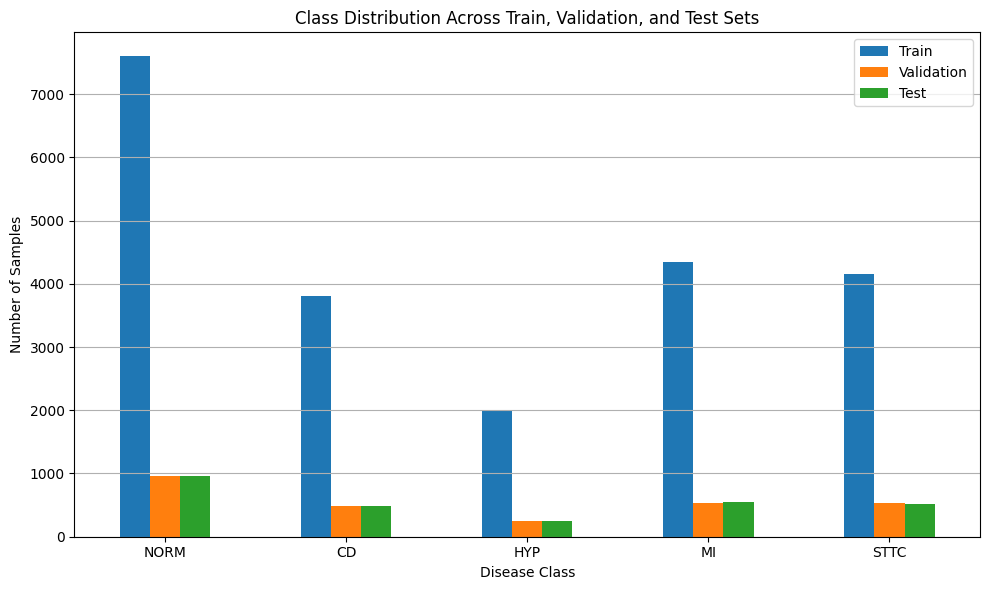

+------------+---------+--------------+--------+---------+
| Subclass   |   Train |   Validation |   Test |   Total |
+============+=========+==============+========+=========+
| NORM       |    7596 |          955 |    963 |    9514 |
+------------+---------+--------------+--------+---------+
| LAFB/LPFB  |    1392 |          179 |    170 |    1741 |
+------------+---------+--------------+--------+---------+
| IRBBB      |     848 |          102 |    108 |    1058 |
+------------+---------+--------------+--------+---------+
| ILBBB      |      62 |            7 |      8 |      77 |
+------------+---------+--------------+--------+---------+
| CLBBB      |     427 |           54 |     54 |     535 |
+------------+---------+--------------+--------+---------+
| CRBBB      |     387 |           52 |     50 |     489 |
+------------+---------+--------------+--------+---------+
| _AVB       |     651 |           81 |     79 |     811 |
+------------+---------+--------------+--------+--------

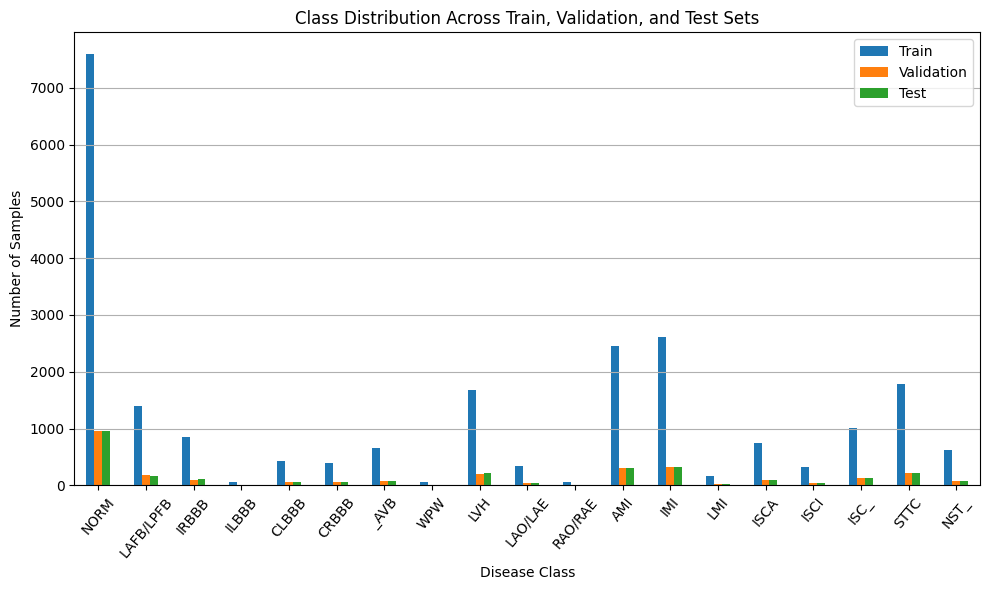

In [8]:
index_to_label = {v: k for k, v in label_map.items()}
# Convert one-hot to class labels
# num_classes = y_train.shape[1]  # Assuming y_train is the one-hot encoded matrix
# y_train_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_train], dtype=int)
# y_val_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_val], dtype=int)
# y_test_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_test], dtype=int)
num_y_train = np.sum(y_train_filtered, axis=0, dtype=int)
num_y_val = np.sum(y_val_filtered, axis=0, dtype=int)
num_y_test = np.sum(y_test_filtered, axis=0, dtype=int)


# Align the indices (classes 0–4)
all_classes = range(len(label_map))


# Prepare table for tabulate
table = []
for idx in all_classes:
    label = index_to_label[idx]
    table.append([label, num_y_train[idx], num_y_val[idx], num_y_test[idx], num_y_train[idx] + num_y_val[idx] + num_y_test[idx]])

from tabulate import tabulate
print(tabulate(table, headers=["Subclass", "Train", "Validation", "Test", "Total"], tablefmt="grid"))
# Combine into DataFrame for plotting
df = pd.DataFrame({
    'Train': num_y_train,
    'Validation': num_y_val,
    'Test': num_y_test
})
df.index = df.index.map(index_to_label)

# Plot
plt.figure(figsize=(10, 6))  # Width=10, Height=6
df.plot(kind='bar', ax=plt.gca())
plt.title("Class Distribution Across Train, Validation, and Test Sets")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

index_to_sub_label = {v: k for k, v in label_map_sub.items()}
# Convert one-hot to class labels
# num_classes = y_train.shape[1]  # Assuming y_train is the one-hot encoded matrix
# y_train_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_train], dtype=int)
# y_val_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_val], dtype=int)
# y_test_labels = np.array([np.isin(np.arange(num_classes), np.where(sample == 1)[0]) for sample in y_test], dtype=int)
num_z_train = np.sum(z_train_filtered, axis=0, dtype=int)
num_z_val = np.sum(z_val_filtered, axis=0, dtype=int)
num_z_test = np.sum(z_test_filtered, axis=0, dtype=int)


# Align the indices (classes 0–4)
all_classes = range(len(label_map_sub))


# Prepare table for tabulate
table = []
for idx in all_classes:
    label = index_to_sub_label[idx]
    table.append([label, num_z_train[idx], num_z_val[idx], num_z_test[idx], num_z_train[idx] + num_z_val[idx] + num_z_test[idx]])

from tabulate import tabulate
print(tabulate(table, headers=["Subclass", "Train", "Validation", "Test", "Total"], tablefmt="grid"))
# Combine into DataFrame for plotting
df = pd.DataFrame({
    'Train': num_z_train,
    'Validation': num_z_val,
    'Test': num_z_test,
})
df.index = df.index.map(index_to_sub_label)

# Plot
plt.figure(figsize=(10, 6))  # Width=10, Height=6
df.plot(kind='bar', ax=plt.gca())
plt.title("Class Distribution Across Train, Validation, and Test Sets")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=50)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np
from imblearn.over_sampling import SMOTENC
from torch.utils.data import DataLoader, TensorDataset

# Placeholder data (Replace with actual data)


# Flatten X_train from (B, 1000, 12) to (B, 1000 * 12)
X_train_flattened = X_train_filtered.reshape(X_train_filtered.shape[0], -1)

# Create ghost categorical features (binary, random)
ghost_categorical_features = np.random.randint(0, 2, size=(X_train_flattened.shape[0], 5))  # 5 ghost categorical features

# Combine the ghost features with the original data (numerical features)
X_train_combined = np.hstack((X_train_flattened, ghost_categorical_features))  # Shape (B, 1000 * 12 + 5)

# Convert data to torch tensors
x_train = torch.from_numpy(X_train_combined).float()  # Shape (B, 1000 * 12 + 5)
labels_train = torch.from_numpy(y_train_filtered).float()  # Shape (B, 5)
sub_labels_train = torch.from_numpy(z_train_filtered).float()  # Shape (B, 20)

# Define a boolean mask indicating categorical features (indicating the ghost columns are categorical)
categorical_features = [True] * ghost_categorical_features.shape[1] + [False] * X_train_flattened.shape[1]

# Prepare empty lists for the resampled data
x_resampled_list = []
y_resampled_list = []

# Apply SMOTENC to each label independently
smote = SMOTENC(categorical_features=categorical_features, random_state=42)

# Apply SMOTE for each column in sub_labels_train (per label)
for i in range(sub_labels_train.shape[1]):
    # Resample each binary target independently
    smote_result = smote.fit_resample(x_train.numpy(), sub_labels_train.numpy()[:, i])
    
    # Collect the resampled data for this label
    x_resampled_list.append(smote_result[0])
    y_resampled_list.append(smote_result[1])

# Concatenate resampled data
x_resampled = np.concatenate(x_resampled_list, axis=1)  # Shape (new B, 1000 * 12 + 5)
y_resampled = np.column_stack(y_resampled_list)  # Shape (new B, 20)

# Convert back to torch tensors
x_resampled = torch.from_numpy(x_resampled).float()
y_resampled = torch.from_numpy(y_resampled).float()

# Create new TensorDataset and DataLoader
train_dataset_resampled = TensorDataset(x_resampled, labels_train, y_resampled)
train_loader_resampled = DataLoader(train_dataset_resampled, batch_size=32, shuffle=True)

# Continue with your DataLoader setup for validation and testing


In [ ]:
x_train = torch.from_numpy(X_train_filtered).float()  # float tensor for input
labels_train = torch.from_numpy(y_train_filtered).float()  # float tensor for labels
sub_labels_train = torch.from_numpy(z_train_filtered).float()

x_val = torch.from_numpy(X_val_filtered).float()
labels_val = torch.from_numpy(y_val_filtered).float()
sub_labels_val = torch.from_numpy(z_val_filtered).float()

x_test = torch.from_numpy(X_test_filtered).float()
lables_test = torch.from_numpy(y_test_filtered).float()
sub_labels_test = torch.from_numpy(z_test_filtered).float()

batch_size = 32

train_dataset = TensorDataset(x_train, labels_train, sub_labels_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(x_val, labels_val, sub_labels_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test = TensorDataset(x_test, lables_test, sub_labels_test)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------
# 1. Squeeze-and-Excitation Block
# ----------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: [B, C, T]
        b, c, t = x.size()
        y = self.global_pool(x).view(b, c)        # [B, C]
        y = self.fc(y).view(b, c, 1)              # [B, C, 1]
        return x * y                              # Scale channels

# ----------------------------
# 2. SE-ResNet Block
# ----------------------------
class SEResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SEResNetBlock, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.se = SEBlock(out_channels)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.se(x)
        return x

# ----------------------------
# 3. CoT Block (Simplified as 1x1 Conv + Attention-like structure)
# ----------------------------
class CoTBlock(nn.Module):
    def __init__(self, channels):
        super(CoTBlock, self).__init__()
        self.conv1x1 = nn.Conv1d(channels, channels, kernel_size=1)
        self.attn = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=1, groups=channels),
            nn.BatchNorm1d(channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        identity = x
        x = self.conv1x1(x)
        attn_weights = self.attn(x)
        return x * attn_weights + identity

# ----------------------------
# 4. Multi-task Model
# ----------------------------
class ECGMultiTaskNet(nn.Module):
    def __init__(self, in_channels=12, base_channels=64, hidden_size=128):
        super(ECGMultiTaskNet, self).__init__()

        # Shared SE-ResNet Block
        self.backbone = SEResNetBlock(in_channels, base_channels)

        
        # Main task branch
        self.main_cot = CoTBlock(base_channels)
        self.main_bigru = nn.GRU(base_channels, hidden_size, bidirectional=True, batch_first=True)

        # Auxiliary task branch
        self.aux_cot = CoTBlock(base_channels)
        self.aux_bigru = nn.GRU(base_channels, hidden_size, bidirectional=True, batch_first=True)
        
        self.fusion_fc = nn.Sequential(
            nn.Linear(hidden_size * 4, hidden_size * 2),  
            nn.ReLU()
        )
        self.fc_main = nn.Linear(hidden_size * 2, 5)  # 5 binary outputs
        self.fc_aux = nn.Linear(hidden_size * 2, 19)  # 23 binary outputs

    def forward(self, x):
        # Input shape: [B, T, C] -> need to permute to [B, C, T]
        x = x.permute(0, 2, 1)  # [B, C, T]

        x = self.backbone(x)   # [B, C', T']

        # Transpose for GRU: [B, C, T] → [B, T, C]
        x_for_gru = x.permute(0, 2, 1)

        # Main task
        x_main = self.main_cot(x)
        x_main = x_main.permute(0, 2, 1)
        out_main, _ = self.main_bigru(x_main)
        out_main = out_main[:, -1, :]
        


        # Auxiliary task
        x_aux = self.aux_cot(x)
        x_aux = x_aux.permute(0, 2, 1)
        out_aux, _ = self.aux_bigru(x_aux)
        out_aux = out_aux[:, -1, :]
        
        fused = torch.cat([out_main, out_aux], dim=1)  # [B, 4*hidden_size]
        
        fused = self.fusion_fc(fused)                  # [B, 2*hidden_size]
        output1 = self.fc_main(fused)  # logits for 5 binary classes
        output2 = self.fc_aux(fused)    # logits for 23 binary classes

        return output1, output2

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ECGMultiTaskNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

In [9]:
def multi_task_loss(output_main, target_main, output_aux, target_aux, model):
    criterion = nn.BCEWithLogitsLoss()
    loss_main = criterion(output_main, target_main)
    loss_aux = criterion(output_aux, target_aux)

    #weighted_loss = (main_weight * weights[0] * loss_main) + (aux_weight * weights[1] * loss_aux)
    #weighted_loss = (lambda_weight * loss_main) + ((1-lambda_weight) * loss_aux)
    weighted_loss = (loss_main) + (0.5 * loss_aux)

    return weighted_loss, loss_main.item(), loss_aux.item()

In [10]:
# 4. Training loop
num_epochs = 15
best_val_loss = float('inf')
best_model_wts = None  # To save the best model
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_main_loss = 0.0
    train_aux_loss = 0.0
    for inputs, targets, sub_targets in train_loader:
        inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)

        optimizer.zero_grad()
        outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
        loss, train_lm, train_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        train_main_loss += train_lm * inputs.size(0)
        train_aux_loss += train_la * inputs.size(0)

    train_loss /= len(train_loader.dataset)
    train_main_loss /= len(train_loader.dataset)
    train_aux_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    val_main_loss = 0.0
    val_aux_loss = 0.0
    with torch.no_grad():
        for inputs, targets, sub_targets in val_loader:
            inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
            
            outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
            loss_, val_lm, val_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
            val_loss += loss_.item() * inputs.size(0)
            val_main_loss += val_lm * inputs.size(0)
            val_aux_loss += val_la * inputs.size(0)

    val_loss /= len(val_loader.dataset)
    val_main_loss /= len(val_loader.dataset)
    val_aux_loss /= len(val_loader.dataset)
    
    # Print with color and progress bar
    epoch_str = f"\033[1;36mEpoch {epoch+1}/{num_epochs}\033[0m"
    bar_len = 30
    filled_len = int(round(bar_len * (epoch+1) / float(num_epochs)))
    bar = '=' * filled_len + '-' * (bar_len - filled_len)
    print(f"{epoch_str} [{bar}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Loss Train Main: {train_main_loss:.4f}, Loss Train Aux: {train_aux_loss:.4f} | Loss Val Main: {val_main_loss:.4f}, Loss Val Aux: {val_aux_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"Found best save with Val Loss: {val_loss:.4f}")
        best_model_wts = model.state_dict()  # Save the best model
        epochs_without_improvement = 0  # Reset the counter
        
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
model.eval()
test_loss = 0.0
criterion = nn.BCEWithLogitsLoss()  # or your chosen loss

with torch.no_grad():
    for inputs, targets, sub_targets in test_loader:
        inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
        
        outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
        loss, test_lm, test_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
        test_loss += loss.item() * inputs.size(0)

test_loss /= len(test_loader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/15 [==----------------------------] | Train Loss: 0.5021 | Val Loss: 0.4107
Loss Train Main: 0.4135, Loss Train Aux: 0.1772 | Loss Val Main: 0.3379, Loss Val Aux: 0.1456
Found best save with Val Loss: 0.4107
Epoch 2/15 [====--------------------------] | Train Loss: 0.3782 | Val Loss: 0.3969
Loss Train Main: 0.3109, Loss Train Aux: 0.1346 | Loss Val Main: 0.3276, Loss Val Aux: 0.1385
Found best save with Val Loss: 0.3969
Epoch 3/15 [======------------------------] | Train Loss: 0.3499 | Val Loss: 0.3645
Loss Train Main: 0.2870, Loss Train Aux: 0.1257 | Loss Val Main: 0.3002, Loss Val Aux: 0.1286
Found best save with Val Loss: 0.3645
Epoch 4/15 [========----------------------] | Train Loss: 0.3316 | Val Loss: 0.3618
Loss Train Main: 0.2718, Loss Train Aux: 0.1196 | Loss Val Main: 0.2975, Loss Val Aux: 0.1286
Found best save with Val Loss: 0.3618
Epoch 5/15 [==========--------------------] | Train Loss: 0.3181 | Val Loss: 0.3514
Loss Train Main: 0.2606, Loss Train Aux: 0.1149 | Lo

In [11]:
def performance_evaluation(model=model, dataset = test_loader, dataset_name = "Test Set"):
    
    all_targets = []
    all_preds = []
    all_sub_targets = []
    all_sub_preds = []

    model.eval()
    with torch.no_grad():
        for inputs, targets, sub_targets in dataset:
            inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
            outputs_main, output_aux = model(inputs)
            probs = torch.sigmoid(outputs_main)
            preds = (probs > 0.5).int()
            
            probs_sub = torch.sigmoid(output_aux)
            preds_sub = (probs_sub > 0.5).int()

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_sub_targets.append(sub_targets.cpu().numpy())
            all_sub_preds.append(preds_sub.cpu().numpy())

    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)
    all_sub_targets = np.vstack(all_sub_targets)
    all_sub_preds = np.vstack(all_sub_preds)
    
    num_classes = all_targets.shape[1]
    num_sub_classes = all_sub_targets.shape[1]

    # Prepare table data
    table_data = []
    table_sub_data = []
    headers = ["Class", "Precision", "Recall (Sensitivity)", "Specificity", "F1-Score", "TN", "FP", "FN", "TP"]

    for i in range(len(label_map)):
        key, value = list(label_map.items())[i]
        y_true = all_targets[:, i]
        y_pred = all_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            # Format with percentage
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_data.append([
            key,
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{specificity:.4f}",
            f"{f1_score:.4f}",
            TN_str,
            FP_str,
            FN_str,
            TP_str,
        ])
    for i in range(len(label_map_sub)):
        key, value = list(label_map_sub.items())[i]
        y_true = all_sub_targets[:, i]
        y_pred = all_sub_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            # Format with percentage
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_sub_data.append([
            key,
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{specificity:.4f}",
            f"{f1_score:.4f}",
            TN_str,
            FP_str,
            FN_str,
            TP_str,
        ])
    print(f"\n------------Performance Evaluation Metrics per Class({dataset_name}) -----------\n")
    print(tabulate(table_data, headers=headers, tablefmt="grid"))
    print(tabulate(table_sub_data, headers=headers, tablefmt="grid"))
    return all_targets, all_preds

In [12]:
targets_train, preds_train = performance_evaluation(model, train_loader, "Train Set")
targets_val, preds_val = performance_evaluation(model, val_loader, "Val Set")
targets_test, preds_test = performance_evaluation(model, test_loader, "Test Set")


------------Performance Evaluation Metrics per Class(Train Set) -----------

+---------+-------------+------------------------+---------------+------------+---------------+------------+------------+--------------+
| Class   |   Precision |   Recall (Sensitivity) |   Specificity |   F1-Score | TN            | FP         | FN         | TP           |
+=========+=============+========================+===============+============+===============+============+============+==============+
| NORM    |      0.9311 |                 0.8965 |        0.9479 |     0.9135 | 9191 (53.1%)  | 505 (2.9%) | 787 (4.5%) | 6820 (39.4%) |
+---------+-------------+------------------------+---------------+------------+---------------+------------+------------+--------------+
| CD      |      0.9472 |                 0.7501 |        0.9882 |     0.8372 | 13338 (77.1%) | 159 (0.9%) | 951 (5.5%) | 2855 (16.5%) |
+---------+-------------+------------------------+---------------+------------+---------------+-----

In [13]:
def plot_confusion_matrix_per_class_multi(y_true_list, y_pred_list, class_names=None, set_names=None):
    """
    Plot confusion matrices for multiple sets (e.g., test, val, train) in columns.
    y_true_list, y_pred_list: list of arrays, each for a set.
    set_names: list of names for each set.
    """
    metric_label = ["TN", "FP", "FN", "TP"]
    num_sets = len(y_true_list)
    num_classes = y_true_list[0].shape[1]
    if set_names is None:
        set_names = [f"Set {i+1}" for i in range(num_sets)]
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]

    for class_idx in range(num_classes):
        fig, axes = plt.subplots(1, num_sets, figsize=(5*num_sets, 4))
        if num_sets == 1:
            axes = [axes]
        for set_idx in range(num_sets):
            y_true = y_true_list[set_idx][:, class_idx]
            y_pred = y_pred_list[set_idx][:, class_idx]
            cm = confusion_matrix(y_true, y_pred)
            total = np.sum(cm)
            if cm.size == 4:
                annot = np.empty_like(cm).astype(str)
                for r in range(2):
                    for c in range(2):
                        count = cm[r, c]
                        row_sum = np.sum(cm[r, :])
                        row_percent = 100 * count / row_sum if row_sum > 0 else 0
                        annot[r, c] = f"{count}\n({metric_label[r*2+c]}:{row_percent:.1f}%)"
            else:
                annot = cm
            sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                        xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'],
                        ax=axes[set_idx])
            axes[set_idx].set_title(f"{set_names[set_idx]}")
            axes[set_idx].set_xlabel('Predicted label')
            axes[set_idx].set_ylabel('True label')
        plt.suptitle(f'Confusion Matrix - {class_names[class_idx]}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

confusion_matrix (Test Set)


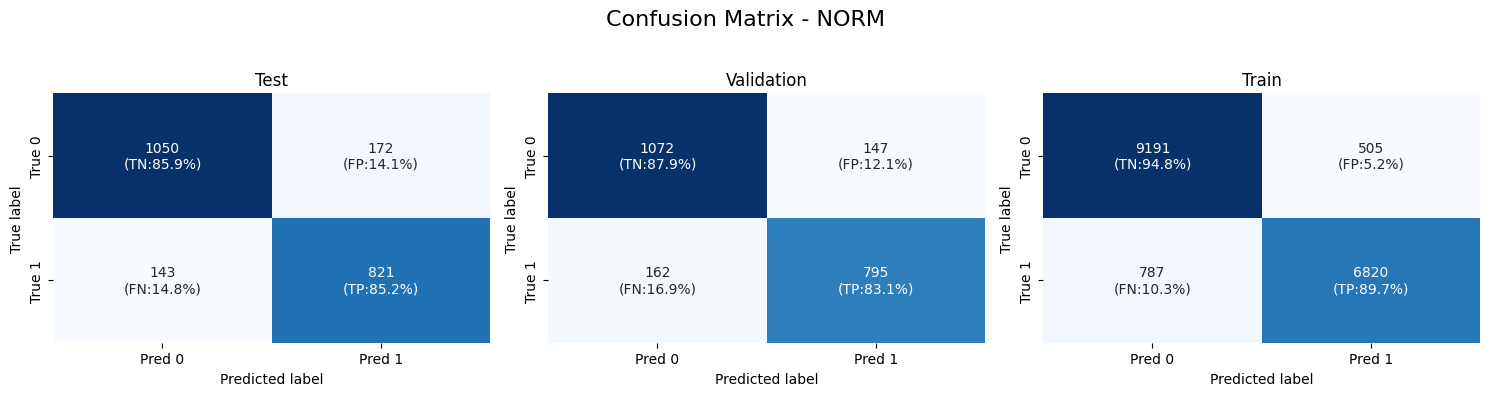

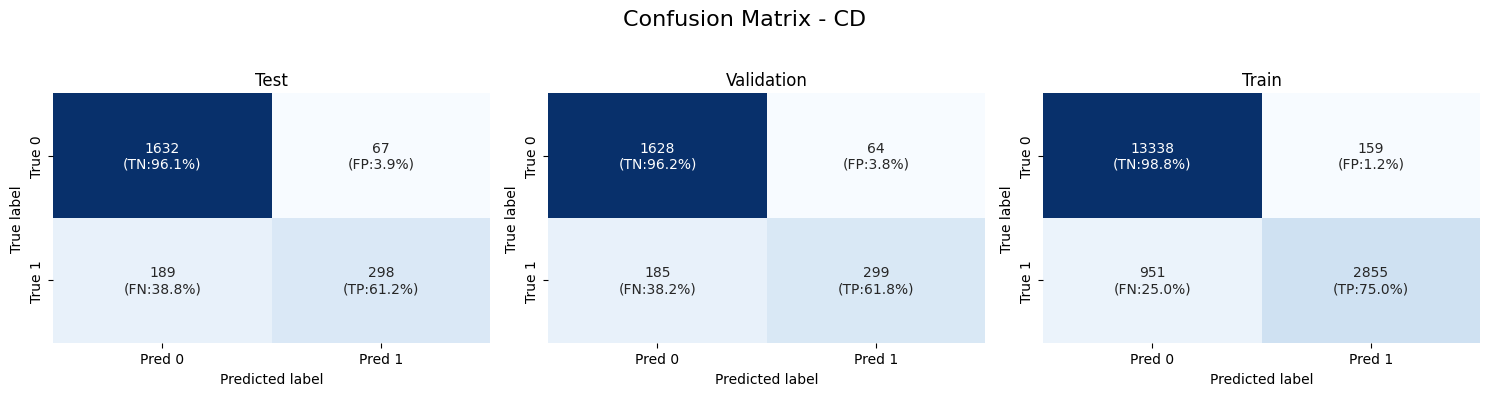

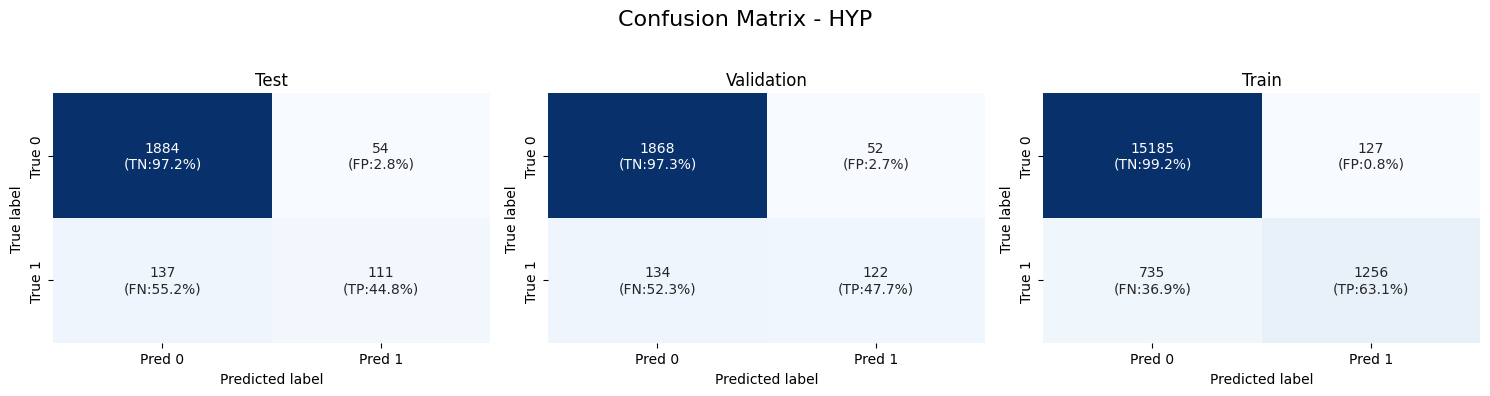

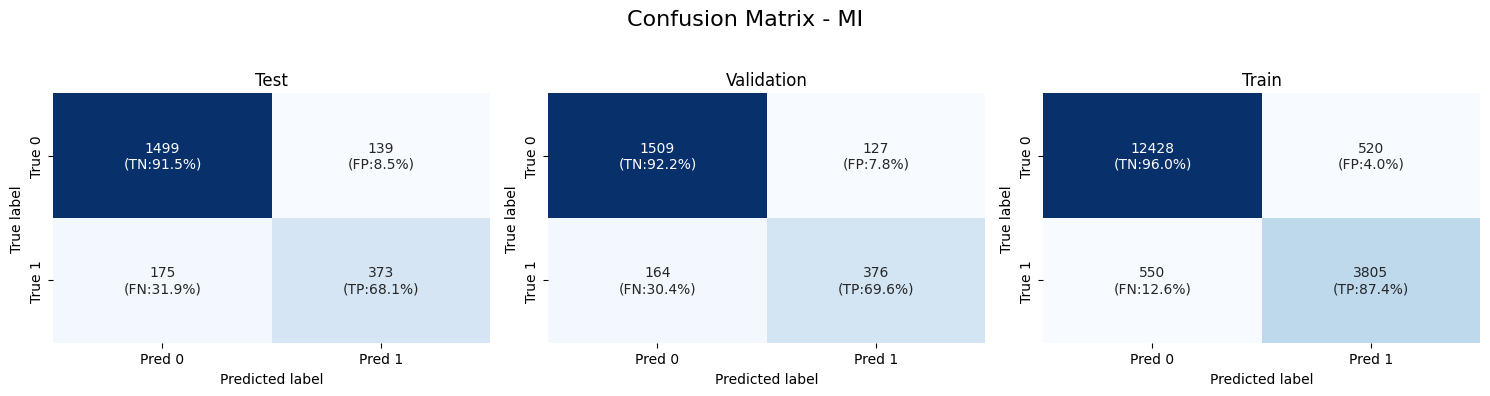

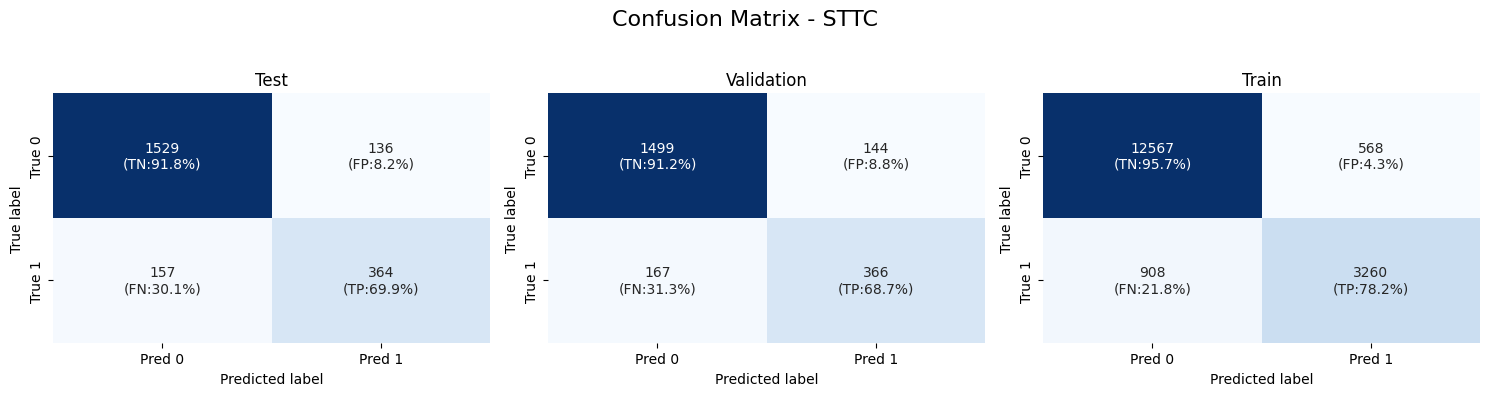

In [14]:
print("confusion_matrix (Test Set)")
#plot_confusion_matrix_per_class(targets_test, preds_test, list(classes_name.keys()))
set_names = ["Test", "Validation", "Train"]
plot_confusion_matrix_per_class_multi(
    [targets_test, targets_val, targets_train],
    [preds_test, preds_val, preds_train],
    class_names=list(label_map.keys()),
    set_names=set_names
)